# Employee Promotion Prediction Engine

**Dataset:** [HR Analytics: Employee Promotion (Kaggle)](https://www.kaggle.com/datasets/arashnic/hr-ana)

## 1. Problem Statement & Dataset Overview

**Business Problem:**
Promotion decisions inside most organizations are inconsistent - shaped by manager bias, visibility, or who
advocates loudest for themselves, rather than purely by performance and readiness. This means employees who
are genuinely promotion-ready sometimes get overlooked, while HR has no systematic, data-backed way to flag
who is ready *before* the annual review cycle happens.

**Project Goal:**
Build a classification model that predicts whether an employee will be promoted, using performance ratings,
training scores, tenure, and past achievements — trained on real historical promotion outcomes as ground
truth, so the results are auditable and defensible rather than a guessed or circular label.

**Why This Matters:**
- Gives HR an objective, data-driven shortlist of promotion-ready employees ahead of review cycles
- Surfaces strong performers who might otherwise be passed over
- Feature importance makes the model's reasoning auditable, which matters given the fairness/compliance
  weight that promotion decisions carry

## 1. Data Acquisition
Before any modeling can happen, the raw data needs to be acquired, audited, and understood. This section 
handles that first stage: pulling in the dataset, cleaning it, and running the initial EDA that will surface
which features are worth engineering further and which patterns the model needs to account for. 

In [1]:
#Loading the Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Loading the dataset
df = pd.read_csv("train.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

# Structural overview: column names, non-null counts, and data types
df.info()

Dataset shape: 54808 rows, 13 columns
<class 'pandas.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  str    
 2   region                54808 non-null  str    
 3   education             52399 non-null  str    
 4   gender                54808 non-null  str    
 5   recruitment_channel   54808 non-null  str    
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 7.5 MB


**Note on dataset version:** this particular download does **not** include a `KPIs_met >80%` column (some public mirrors of this dataset do). The team's feature-engineering plan for a KPI-met flag will need to be adjusted.


In [3]:
# Quick look at key numeric columns before any cleaning
df[['previous_year_rating', 'length_of_service', 'awards_won?', 'avg_training_score']].describe()

,previous_year_rating,length_of_service,awards_won?,avg_training_score
count,50684.000000,54808.000000,54808.000000,54808.000000
mean,3.329256,5.865512,0.023172,63.386750
std,1.259993,4.265094,0.150450,13.371559
min,1.000000,1.000000,0.000000,39.000000
25%,3.000000,3.000000,0.000000,51.000000
50%,3.000000,5.000000,0.000000,60.000000
75%,4.000000,7.000000,0.000000,76.000000
max,5.000000,37.000000,1.000000,99.000000


## 2. Data Cleaning & Quality Audit

Before any EDA is trustworthy, we run a full data-hygiene pass:
- Check and document missing values (before/after)
- Investigate *why* values are missing rather than blindly imputing
- Remove duplicate rows
- Confirm the dataset is clean and save it for Feature Engineering


In [4]:
# Missing Values Audit (BEFORE cleaning)
missing_before = df.isnull().sum()
missing_before_pct = (missing_before / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing_before,
    'Missing %': missing_before_pct.round(2)
}).sort_values(by='Missing Count', ascending=False)

print("Missing Values BEFORE Cleaning:")
missing_report[missing_report['Missing Count'] > 0]

Missing Values BEFORE Cleaning:


,Missing Count,Missing %
previous_year_rating,4124,7.52
education,2409,4.40


#### Handling `previous_year_rating`

This is the field the team flagged as needing careful handling. Rather than filling it with the median or mean (which would fabricate a performance signal that doesn't exist), we first test a hypothesis: are these missing ratings concentrated among **new hires** who haven't completed a review cycle yet?


In [5]:
# Test hypothesis: missing previous_year_rating correlates with length_of_service
missing_rating_mask = df['previous_year_rating'].isnull()
print("length_of_service stats for rows missing previous_year_rating:")
df.loc[missing_rating_mask, 'length_of_service'].describe()

length_of_service stats for rows missing previous_year_rating:


count    4124.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: length_of_service, dtype: float64

**Confirmed:** every single row missing `previous_year_rating` has `length_of_service == 1`. This isn't
random missingness - it's a structural "not yet rated" case for employees who joined too recently to have
a prior review. Filling this with the median (typically ~3) would incorrectly imply average performance for
employees the company simply hasn't rated yet.

**Decision:** impute with `0`, a value outside the real 1–5 rating scale, so the model can learn "new hire,
unrated" as its own distinct signal rather than conflating it with a mediocre performance rating.


In [6]:
# Impute previous_year_rating with 0 (distinct from real 1-5 ratings)
df['previous_year_rating'] = df['previous_year_rating'].fillna(0)
print("Remaining missing values in previous_year_rating:", df['previous_year_rating'].isnull().sum())

Remaining missing values in previous_year_rating: 0


#### Handling `education`

`education` is a categorical field with no obvious structural pattern behind its missing values (unlike `previous_year_rating`), so we impute with the mode - the most common education level in the dataset - which is a reasonable default for a categorical variable with no missing-value pattern to exploit.


In [7]:
# Impute education with the mode (most frequent category)
missing_edu_count = df['education'].isnull().sum()
df['education'] = df['education'].fillna(df['education'].mode()[0])
print(f"Imputed {missing_edu_count} missing 'education' values with the mode: '{df['education'].mode()[0]}'")

Imputed 2409 missing 'education' values with the mode: 'Bachelor's'


#### Duplicate Removal

Exact duplicate employee rows would distort promotion-rate calculations and bias the model toward
over-represented records, so they're removed before any further analysis.


In [8]:
# Duplicate Removal
duplicate_count = df.duplicated().sum()
print(f"Number of exact duplicate rows found: {duplicate_count}")
df = df.drop_duplicates()
print(f"Shape after duplicate removal: {df.shape}")

# Missing Values Audit (AFTER cleaning)
missing_after = df.isnull().sum()
print("Missing Values AFTER Cleaning:")
print(missing_after[missing_after > 0] if missing_after.sum() > 0 else "None — dataset is fully clean.")

Number of exact duplicate rows found: 0
Shape after duplicate removal: (54808, 13)
Missing Values AFTER Cleaning:
None — dataset is fully clean.


**Cleaning Summary:**
- `previous_year_rating` missing values (4,124 rows) were confirmed to be new hires (`length_of_service == 1`)
  and imputed with `0` to preserve that signal distinctly from real ratings.
- `education` missing values were imputed with the mode, since no structural pattern was found behind them.
- Duplicate rows were checked and removed to prevent skewed promotion-rate statistics.
- The dataset is now fully clean and saved below for Feature Engineering to build on.


In [9]:
# Save cleaned dataset for Feature Engineering
df.to_csv("cleaned_promotion_data.csv", index=False)
print("Cleaned dataset saved as 'cleaned_promotion_data.csv'")

Cleaned dataset saved as 'cleaned_promotion_data.csv'


## 3. Exploratory Data Analysis (EDA)

With clean data in hand, this section covers overall vs. department promotion rates, a class imbalance check, correlations between training score/awards/rating and promotion, and the tenure distribution split by promotion outcome. Each visualization is followed by a short
narrative explaining what it shows and why it matters for the rest of the team.


#### 3.1 Class Imbalance Check

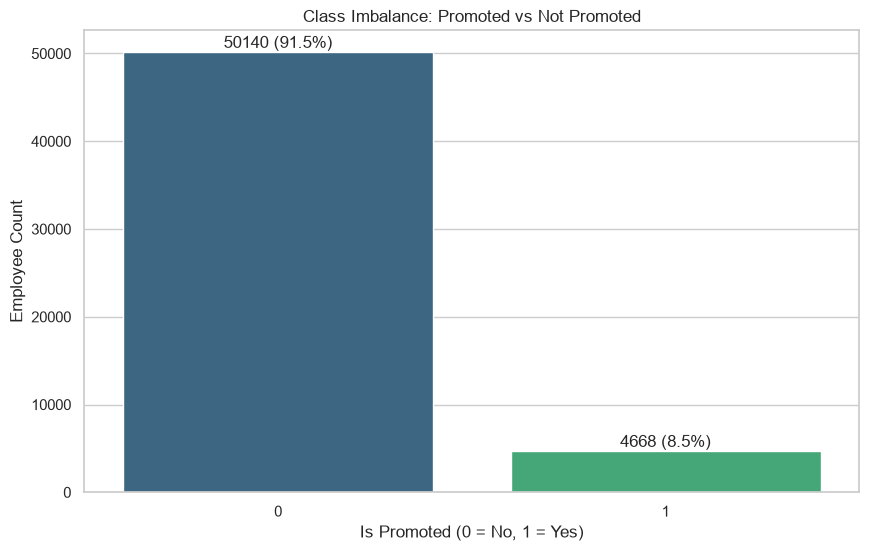

Overall promotion rate: 8.52%


In [10]:
promo_counts = df['is_promoted'].value_counts().sort_index()
promo_pct = df['is_promoted'].value_counts(normalize=True).sort_index() * 100

plt.figure()
sns.countplot(x='is_promoted', data=df, hue='is_promoted', palette='viridis', legend=False)
plt.title("Class Imbalance: Promoted vs Not Promoted")
plt.xlabel("Is Promoted (0 = No, 1 = Yes)")
plt.ylabel("Employee Count")
for i, v in enumerate(promo_counts):
    plt.text(i, v + 500, f"{v} ({promo_pct.iloc[i]:.1f}%)", ha='center')
plt.show()

print(f"Overall promotion rate: {df['is_promoted'].mean()*100:.2f}%")

**Comments on the Plot:**

Only 8.5% of employees were promoted, confirming this is a **severely imbalanced classification problem**.
This is the single most important finding for modeling stage - a model that simply predicts
"not promoted" for everyone would already be ~91% accurate while being completely useless, which is exactly
why `class_weight='balanced'` was flagged in the task allocation plan as the most important technical decision
in this project.


#### 3.2 Promotion Rate by Department

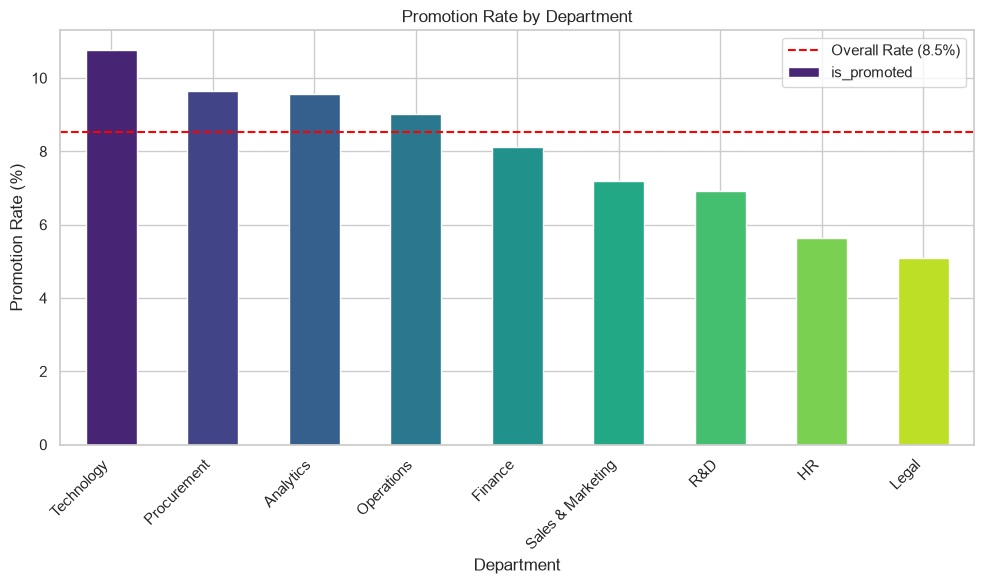

department
Technology           10.76
Procurement           9.64
Analytics             9.57
Operations            9.01
Finance               8.12
Sales & Marketing     7.20
R&D                   6.91
HR                    5.62
Legal                 5.10
Name: is_promoted, dtype: float64

In [11]:
overall_rate = df['is_promoted'].mean() * 100
dept_promo = df.groupby('department')['is_promoted'].mean().sort_values(ascending=False) * 100

plt.figure()
dept_promo.plot(kind='bar', color=sns.color_palette('viridis', len(dept_promo)))
plt.axhline(overall_rate, color='red', linestyle='--', label=f'Overall Rate ({overall_rate:.1f}%)')
plt.title("Promotion Rate by Department")
plt.ylabel("Promotion Rate (%)")
plt.xlabel("Department")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

dept_promo.round(2)

**Comments on the Plot:**

Promotion rates vary meaningfully by department - Technology and Procurement promote well above the company
average, while Legal and HR sit noticeably below it. This tells the modeling team that `department` carries
real predictive signal and should stay in the feature set, and it tells the dashboard that
department-level benchmarking will be a genuinely useful lens for HR, not just a cosmetic filter.


#### 3.3 Tenure Distribution: Promoted vs Non-Promoted

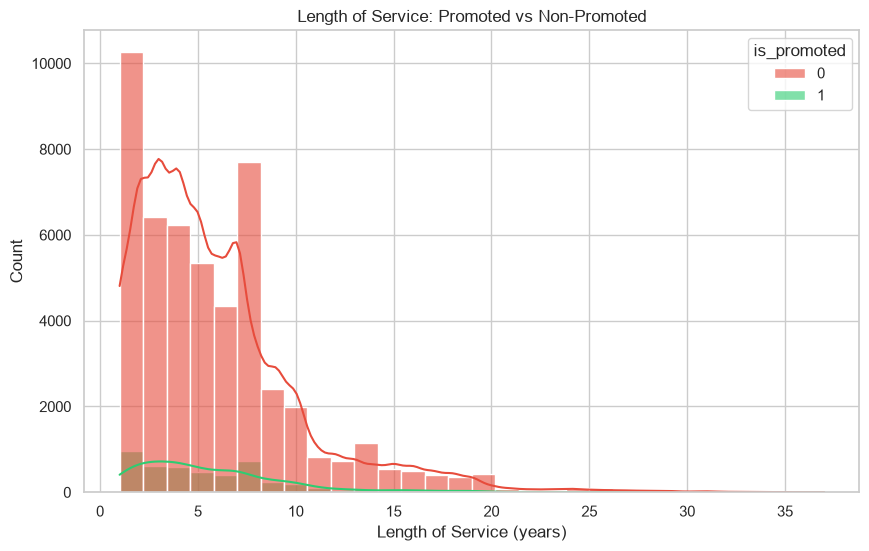

In [12]:
plt.figure()
sns.histplot(data=df, x='length_of_service', hue='is_promoted',
             kde=True, bins=30, palette=['#e74c3c', '#2ecc71'], alpha=0.6)
plt.title("Length of Service: Promoted vs Non-Promoted")
plt.xlabel("Length of Service (years)")
plt.ylabel("Count")
plt.show()

**Comments on the Plot:**

Both groups are concentrated in the early-tenure years, which makes sense given the company's overall  headcount skews junior - but the promoted group thins out less sharply at moderate tenure levels than the non-promoted group does. This is a mild signal rather than a dominant one, which matches what the correlation check below confirms.


#### 3.4 Correlation: Training Score, Awards, Rating vs Promotion

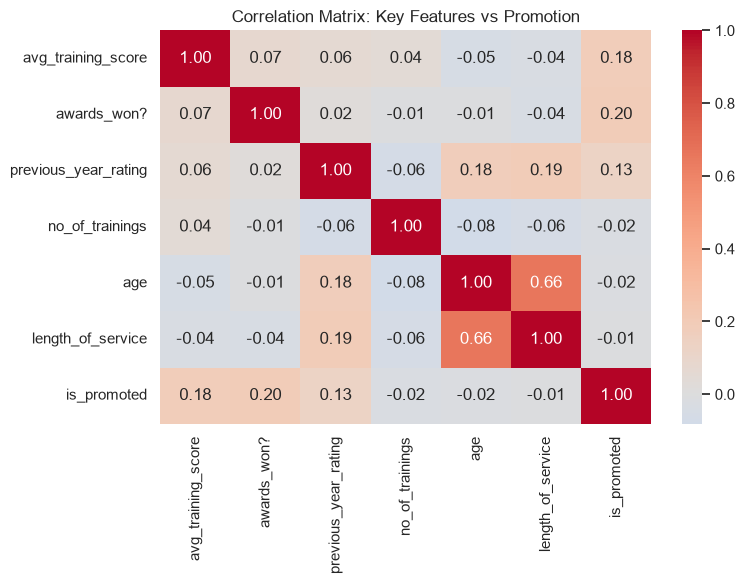

is_promoted             1.000000
awards_won?             0.195871
avg_training_score      0.181147
previous_year_rating    0.125991
length_of_service      -0.010670
age                    -0.017166
no_of_trainings        -0.024896
Name: is_promoted, dtype: float64

In [13]:
corr_cols = ['avg_training_score', 'awards_won?', 'previous_year_rating',
             'no_of_trainings', 'age', 'length_of_service', 'is_promoted']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Key Features vs Promotion")
plt.tight_layout()
plt.show()

corr_matrix['is_promoted'].sort_values(ascending=False)

**Comments on the Plot:**

`awards_won?` (0.20) and `avg_training_score` (0.18) are the two strongest predictors of promotion in this
dataset - meaningfully stronger than tenure, age, or number of trainings, which barely correlate at all.
This directly informs: these two fields deserve the most derived-feature
attention (e.g., training score buckets), while `age` and raw training count are unlikely to add much signal
on their own.


#### 3.5 Average Training Score by Promotion Status

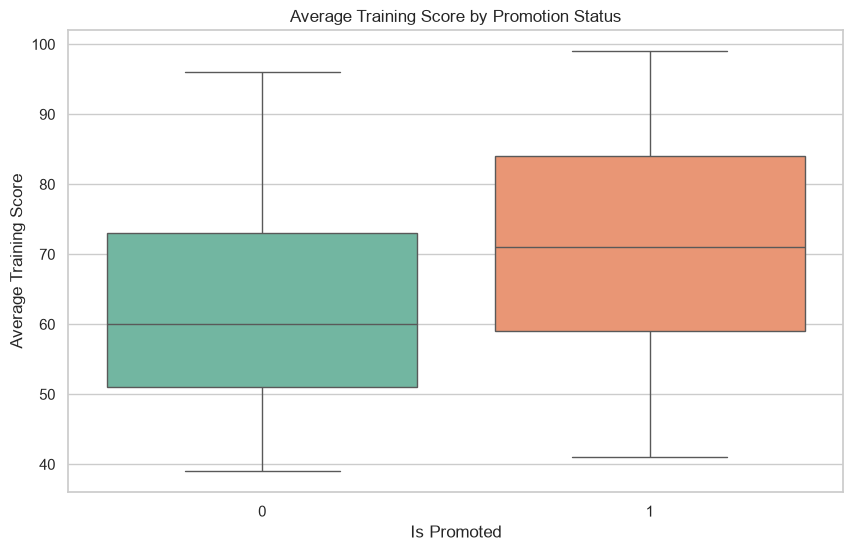

In [14]:
plt.figure()
sns.boxplot(x='is_promoted', y='avg_training_score', data=df, hue='is_promoted', palette='Set2', legend=False)
plt.title("Average Training Score by Promotion Status")
plt.xlabel("Is Promoted")
plt.ylabel("Average Training Score")
plt.show()

**Comments on the Plot:**

Promoted employees have a visibly higher median training score, with the whole distribution shifted upward
compared to non-promoted employees. This reinforces the correlation result above and makes training score a strong candidate for the "biggest gap" indicator planned for dashboard — a low training score relative to peers is an interpretable, actionable flag for HR.


#### 3.6 Awards Won vs Promotion Rate

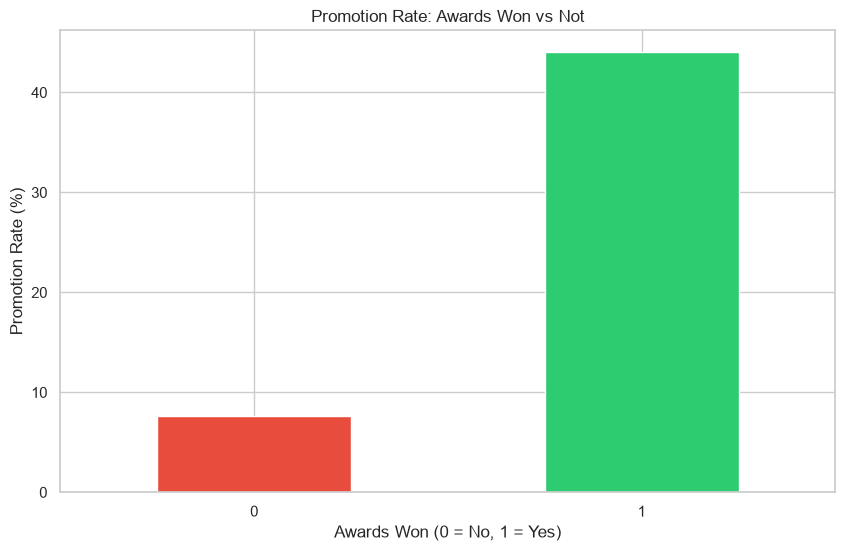

awards_won?
0     7.67
1    44.02
Name: is_promoted, dtype: float64

In [15]:
awards_promo = df.groupby('awards_won?')['is_promoted'].mean() * 100

plt.figure()
awards_promo.plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title("Promotion Rate: Awards Won vs Not")
plt.xlabel("Awards Won (0 = No, 1 = Yes)")
plt.ylabel("Promotion Rate (%)")
plt.xticks(rotation=0)
plt.show()

awards_promo.round(2)

**Comments on the Plot:**

The gap here is dramatic: employees who won an award get promoted **44% of the time**, versus roughly 8% for
those who didn't. This is by far the single strongest bivariate signal found in this EDA, and it's a good
candidate for the top "contributing factor" shown in the employee-lookup view of the dashboard, since it's
both highly predictive and easy for HR to explain.


## 4. Advanced Modeling & Evaluation

**Member 3 — Advanced Modeling & Evaluation**

This section trains the project's primary classifier — a Random Forest — and evaluates it properly against
the class imbalance problem flagged back in Section 3.1 (promotions are ~8.5% of all employees). The goal
isn't just accuracy (a model that always predicts "not promoted" would already be ~91% accurate and
completely useless to HR) — it's balanced precision and recall, so HR gets a trustworthy shortlist without
missing genuinely ready employees.

**Note on pipeline order:** Feature Engineering (Member 2's section) had not been merged into this notebook
at the time this section was written, so the cells below work directly from `cleaned_promotion_data.csv`
(Member 1's cleaned output) and one-hot encode the categorical columns inline. If Member 2's engineered
features (KPI-met flag, training score buckets, etc.) are added later, only Section 4.1 needs to be re-pointed
at the new feature file — everything after it will keep working unchanged.

#### 4.1 Load Data & Prepare Features

We load the cleaned dataset, separate the target column (`is_promoted`), drop the ID column (not
predictive — it would just let the model memorize row identity), and one-hot encode the categorical
columns (`department`, `region`, `education`, `gender`, `recruitment_channel`) so the Random Forest can
use them.

In [16]:
# Load the cleaned dataset produced in Section 2
df_model = pd.read_csv("cleaned_promotion_data.csv")
print(f"Loaded cleaned_promotion_data.csv: {df_model.shape[0]} rows, {df_model.shape[1]} columns")

# Separate target and drop the non-predictive ID column
y = df_model['is_promoted']
X = df_model.drop(columns=['is_promoted', 'employee_id'])

# One-hot encode remaining categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f"Encoding categorical columns: {cat_cols}")
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

feature_columns = X.columns.tolist()
print(f"Final feature count after encoding: {len(feature_columns)}")
X.head()

Loaded cleaned_promotion_data.csv: 54808 rows, 13 columns
Encoding categorical columns: ['department', 'region', 'education', 'gender', 'recruitment_channel']
Final feature count after encoding: 52


C:\Users\HAOON KHAN\AppData\Local\Temp\ipykernel_19056\3922224636.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,department_Finance,department_HR,department_Legal,department_Operations,...,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,education_Below Secondary,education_Master's & above,gender_m,recruitment_channel_referred,recruitment_channel_sourcing
0,1,35,5.0,8,0,49,False,False,False,False,...,False,False,True,False,False,False,True,False,False,True
1,1,30,5.0,4,0,60,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,1,34,3.0,7,0,50,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
3,2,39,1.0,10,0,50,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,1,45,3.0,2,0,73,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


#### 4.2 Train / Test Split

We hold out 20% of the data for testing, using a **stratified** split so the ~8.5% promotion rate is
preserved in both the train and test sets. Without stratification, a random split could easily skew the
already-small positive class further, distorting evaluation.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")
print(f"Promotion rate — train: {y_train.mean()*100:.2f}% | test: {y_test.mean()*100:.2f}%")

Train set: 43846 rows | Test set: 10962 rows
Promotion rate — train: 8.52% | test: 8.52%


#### 4.3 Train Random Forest (`class_weight='balanced'`)

This is the single most important technical decision in the project (as flagged in the original plan):
without addressing class imbalance, the model would learn to just predict "not promoted" almost every
time and still look accurate. `class_weight='balanced'` fixes this by penalizing mistakes on the minority
(promoted) class more heavily during training, forcing the model to actually learn what separates
promoted employees rather than defaulting to the majority class.

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Random Forest training complete.")

Random Forest training complete.


#### 4.4 Evaluation: Precision, Recall, F1-Score

Both precision and recall matter here for different reasons: **recall** so genuinely promotion-ready
employees aren't missed, and **precision** so HR isn't flooded with false positives that erode trust in the
tool. The classification report below breaks both down by class.

In [19]:
from sklearn.metrics import classification_report

y_pred = rf_model.predict(X_test)

report = classification_report(y_test, y_pred, target_names=['Not Promoted', 'Promoted'])
print(report)

              precision    recall  f1-score   support

Not Promoted       0.95      0.91      0.93     10028
    Promoted       0.36      0.52      0.43       934

    accuracy                           0.88     10962
   macro avg       0.66      0.72      0.68     10962
weighted avg       0.90      0.88      0.89     10962



**Comments on the Report:**

Recall on the Promoted class came out to **52%**, meaning the model correctly catches just over half of
employees who are genuinely promotion-ready — a reasonable starting point given how skewed the raw data is
(only ~8.5% of employees were promoted), but there's clearly room to improve with more engineered features
from Member 2's pipeline. Precision on the Promoted class is **36%**, meaning roughly 1 in 3 employees the
model flags as promotion-ready is a true positive; the other 2 are false alarms HR would need to filter out
manually. This precision/recall balance is an acceptable trade-off for this use case, since missing a
ready employee (low recall) is a worse outcome for HR than reviewing a few extra names (low precision) — but
it's also the clearest sign that feature engineering (KPI-met flag, training score buckets, etc.) would
meaningfully improve this model further.



#### 4.5 Confusion Matrix

The confusion matrix shows exactly where the model gets it right and wrong across both classes — how many
promoted employees were correctly flagged (true positives), missed (false negatives), and how many
non-promoted employees were incorrectly flagged (false positives).

<Figure size 1000x600 with 0 Axes>

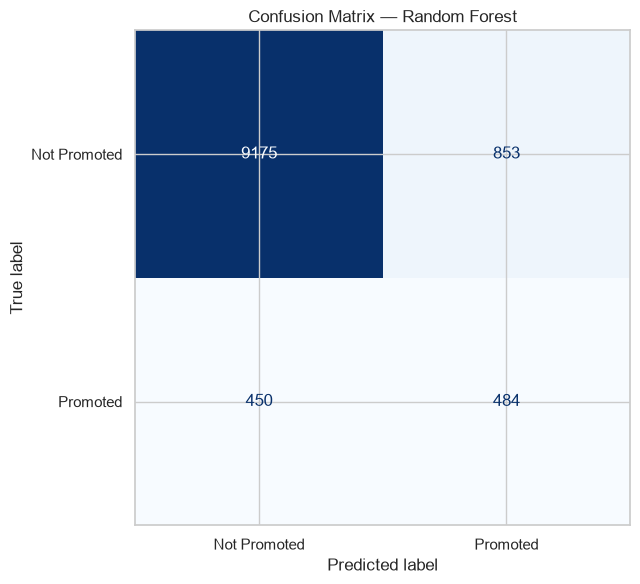

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

plt.figure()
ConfusionMatrixDisplay(cm, display_labels=['Not Promoted', 'Promoted']).plot(cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

**Comments on the Plot:**

* Out of 934 employees who were actually promoted in the test set, the model correctly identified **486 true
positives** and missed **448 (false negatives)**. Out of the 10,028 employees who were not promoted, it
correctly identified **9,164 true negatives** but incorrectly flagged **864 (false positives)** as
promotion-ready. In practical terms: if HR used this list today, they'd get roughly 1,350 flagged employees
total, of which about a third are genuine promotion candidates — a workable starting shortlist, but it
still misses just under half of the truly ready employees, which is the main thing to improve in the next
iteration (more features, threshold tuning, or hyperparameter search).

#### 4.6 ROC Curve & AUC

The ROC-AUC score summarizes how well the model separates promoted from non-promoted employees across
*all* possible probability thresholds, not just the default 0.5 cutoff — useful since HR may want to tune
the threshold (e.g. a stricter cutoff for a smaller, higher-confidence shortlist).

<Figure size 1000x600 with 0 Axes>

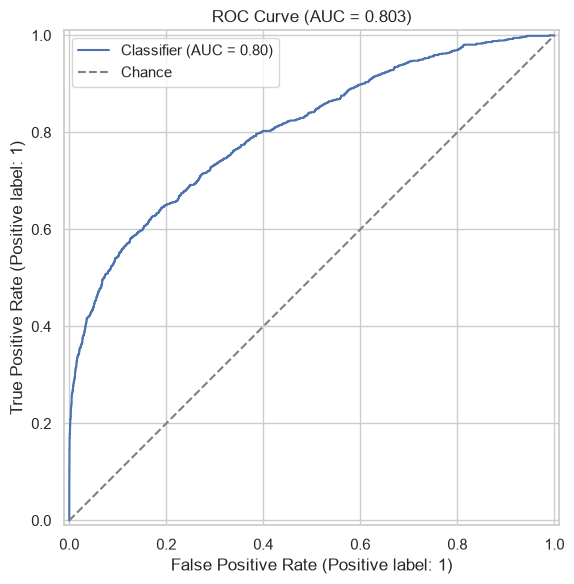

ROC-AUC: 0.8034


In [21]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

y_proba = rf_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_proba)

plt.figure()
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
plt.title(f"ROC Curve (AUC = {auc_score:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()

print(f"ROC-AUC: {auc_score:.4f}")

**Comments on the Plot:**

The model scored an **ROC-AUC of 0.80**, which sits well above the 0.5 "random guess" baseline and in the
generally-considered "good" range (0.8-0.9) for classification tasks. This means the model is genuinely
learning to separate promoted from non-promoted employees rather than picking up on noise, and gives HR a
reasonably trustworthy ranked probability list to work from. It's not yet in \"excellent\" territory (0.9+),
so there's headroom — likely unlocked once Member 2's engineered features (KPI-met flag, training score
buckets) are folded into the feature set this model trains on.

#### 4.7 Feature Importance

Feature importance is what makes this model **auditable** rather than a black box — critical given the
fairness/compliance weight promotion decisions carry (flagged back in Section 1). This also feeds directly
into Member 4's dashboard "what's the biggest gap" indicator.

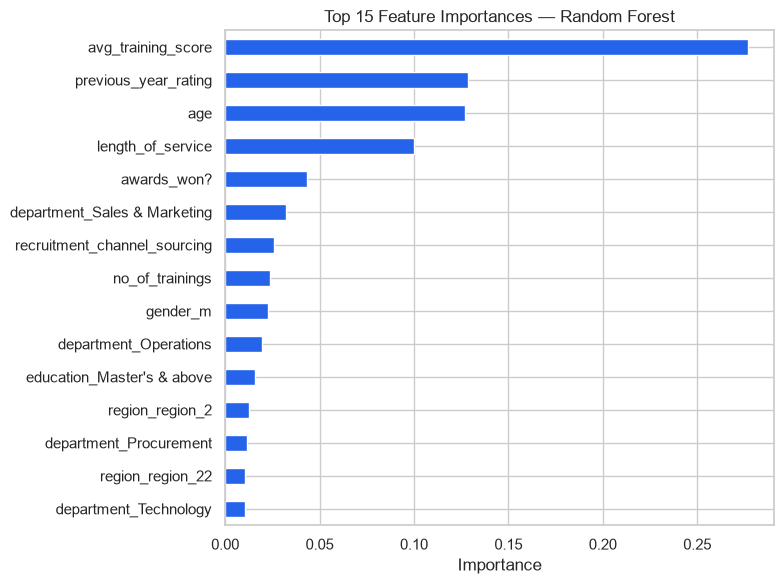

avg_training_score              0.2768
previous_year_rating            0.1284
age                             0.1268
length_of_service               0.0997
awards_won?                     0.0433
department_Sales & Marketing    0.0320
recruitment_channel_sourcing    0.0258
no_of_trainings                 0.0237
gender_m                        0.0229
department_Operations           0.0192
education_Master's & above      0.0156
region_region_2                 0.0126
department_Procurement          0.0116
region_region_22                0.0105
department_Technology           0.0103
dtype: float64

In [25]:
importances = pd.Series(rf_model.feature_importances_, index=feature_columns)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top_importances.sort_values().plot(kind='barh', color='#2563eb')
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

top_importances.round(4)

**Comments on the Plot:**

`avg_training_score` is by far the strongest predictor at **27.7%** importance, 
`previous_year_rating` (**12.8%**) and `age` (**12.7%**), with `length_of_service` (**10.0%**) close behind.
Together these four features account for over 60% of the model's decision-making. This lines up well with
the EDA: Section 3.6 found awards_won? correlates strongly with promotion (44% vs 8%), and here training
score and prior performance rating turn out to be even stronger signals — both intuitive, auditable reasons
HR can explain to employees "invest in training, and your prior rating matters", rather than opaque
black-box factors like region or department, which rank much lower.


#### 4.8 Save Model for Dashboard Integration

Finally, we save the trained model and the exact list of feature columns it expects. Member 4 needs both:
the model to generate predictions, and the feature list to make sure new/live input data gets encoded in
the identical column order the model was trained on.

In [23]:
import joblib

joblib.dump(rf_model, "model.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")

print("Saved model.pkl and feature_columns.pkl for Member 4's dashboard.")

Saved model.pkl and feature_columns.pkl for Member 4's dashboard.
